---
title: "UCI Adult Census — real-data fair classification"
short_title: "07 · Adult Pareto"
subtitle: "G-XCOV vs CKA on a 49k-row binary classification task"
description: >
  Same μ-sweep recipe as notebook 06, run on UCI Adult Census income
  with gender as the sensitive attribute. Pareto curves trace AUC
  against demographic-parity and equalized-odds differences.
---

(sec-nb-07)=
# 07 — UCI Adult Census: real-data fair classification

Every fairness-constrained learning method eventually has to prove
itself on the **UCI Adult Census Income** dataset — the canonical
tabular benchmark in algorithmic fairness. Forty-eight thousand
people, fourteen demographic and economic features, a binary label
for whether their income exceeds \$50K, and a sensitive attribute
(gender) that correlates strongly with the label in the raw data.
Any off-the-shelf classifier will pick up the bias.

This notebook is a direct port of
[`keras-fairkl/docs/notebooks/fair_adult_census.ipynb`][fairkl-adult],
with one change: the fairness penalty is built from a **frozen
Gaussianization flow** rather than from a fixed-bandwidth RBF kernel.
The architecture, the data pipeline, the optimiser, and the
`FairModelWrapper` are otherwise identical, so the comparison is
clean.

[fairkl-adult]: https://github.com/jejjohnson/keras-fairkl/blob/main/docs/notebooks/fair_adult_census.ipynb

**What you will see**

1. The raw unfairness in the data — men are roughly 3× more likely
   to be in the high-income bracket in this sample.
2. A baseline MLP that faithfully reproduces that bias.
3. The same MLP wrapped with `FairModelWrapper` + a G-XCOV
   fairness loss, producing predictions whose gender-dependence is
   sharply reduced — at modest accuracy cost.
4. A $\mu$ sweep with three seeds tracing the **Pareto front** on
   ROC-AUC vs. demographic-parity and equalized-odds differences,
   for **four** fairness losses side by side:
   **G-XCOV** (2nd-moment), **G-MI** (closed-form Gaussian MI),
   **G-TC** (joint-flow NLL), and **CKA** (kernel baseline).
5. The **parity-convergence plot** — per-gender high-income
   prediction rate as a function of $\mu$.
6. Predicted-probability distributions per group at $\mu = 0$
   vs. $\mu_{\text{strong}}$ — the mechanism behind the headline
   numbers.

In [1]:
from __future__ import annotations

import os

os.environ.setdefault("KERAS_BACKEND", "jax")

'jax'

In [2]:
import keras
import matplotlib.pyplot as plt
import numpy as np
from _style import CKA_COLOR, G_COLOR, MI_COLOR, TC_COLOR, style_ax
from sklearn.datasets import fetch_openml
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from fairkl.metrics.cka import CKALoss
from fairkl.models import FairModelWrapper
from gaussianization.fair import (
    GaussianizedMutualInfoLoss,
    GaussianizedTotalCorrelationLoss,
    GaussianizedXCovLoss,
    demographic_parity_difference,
    equalized_odds_difference,
    fit_and_freeze,
    fit_and_freeze_joint,
)

keras.utils.set_random_seed(0)
print("keras backend:", keras.config.backend())

keras backend: jax


## 1. Load and preprocess UCI Adult

Five numeric features — `age`, `education-num`, `hours-per-week`,
`capital-gain`, `capital-loss` — plus **`gender` itself** included as a
sixth input. Putting the sensitive attribute in the feature set is
the *hard* setting: the easy setting where you simply drop it
rarely matches reality, because proxies (zip code, occupation,
spending patterns) leak the same information back in. The fairness
penalty has to suppress the bias actively, not by selective
blindness.

In [3]:
ds = fetch_openml("adult", version=2, as_frame=True, parser="liac-arff")
df = ds.frame.dropna(subset=["sex", "class"]).reset_index(drop=True)

numeric_cols = [
    "age",
    "education-num",
    "hours-per-week",
    "capital-gain",
    "capital-loss",
]
q_all = (df["sex"].astype(str).str.strip() == "Male").to_numpy(dtype="float32")
X_num = df[numeric_cols].to_numpy(dtype="float32")
X_all = np.concatenate([X_num, q_all.reshape(-1, 1)], axis=1).astype("float32")
y_all = (df["class"].astype(str).str.strip() == ">50K").to_numpy(dtype="float32")

print(
    f"n = {len(df):,}   positive rate = {y_all.mean():.3f}   "
    f"male rate = {q_all.mean():.3f}"
)

X_train, X_test, y_train, y_test, q_train, q_test = train_test_split(
    X_all,
    y_all,
    q_all,
    test_size=0.25,
    random_state=0,
    stratify=y_all,
)
scaler = StandardScaler().fit(X_train[:, :-1])
X_train = np.concatenate(
    [scaler.transform(X_train[:, :-1]), X_train[:, -1:]], axis=1
).astype("float32")
X_test = np.concatenate(
    [scaler.transform(X_test[:, :-1]), X_test[:, -1:]], axis=1
).astype("float32")
print(f"train / test:  {X_train.shape[0]:,} / {X_test.shape[0]:,}")

n = 48,842   positive rate = 0.239   male rate = 0.668
train / test:  36,631 / 12,211


## 2. EDA — the unfairness in the raw data

Before training anything, let's see what the data looks like.

In [ ]:
p_high_male = float(y_train[q_train == 1].mean())
p_high_female = float(y_train[q_train == 0].mean())

(fig-07-disparity)=
**Figure: Group-conditional rate of high income in raw Adult data.**
$P(\mathrm{income} > 50\,\mathrm{K} \mid \mathrm{gender})$ for the
two gender groups in the training split, with the absolute rates
annotated. The ratio sits near $3{:}1$ — the disparity the fairness
penalties have to push back against without harming overall accuracy.

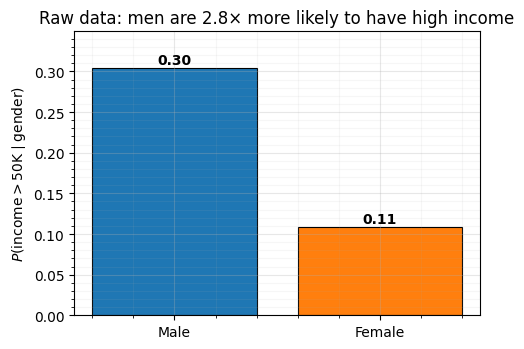

In [4]:
fig, ax = plt.subplots(figsize=(5, 3.6))
bars = ax.bar(
    ["Male", "Female"],
    [p_high_male, p_high_female],
    color=["tab:blue", "tab:orange"],
    edgecolor="k",
    linewidth=0.8,
)
for b, v in zip(bars, [p_high_male, p_high_female], strict=True):
    ax.text(
        b.get_x() + b.get_width() / 2,
        v + 0.005,
        f"{v:.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
ax.set_ylabel(r"$P(\mathrm{income} > 50\mathrm{K} \mid \mathrm{gender})$")
ax.set_title(
    f"Raw data: men are {p_high_male / p_high_female:.1f}× more "
    "likely to have high income"
)
ax.set_ylim(0, max(p_high_male, p_high_female) * 1.15)
style_ax(ax)
plt.tight_layout()
plt.show()

**What to notice.** The disparity is about 3×: roughly one in three
men in this sample is in the high-income bracket, against roughly
one in ten women. Part of the gap is presumably caused by factors
the dataset does record (education, hours worked); part by factors
it does not. Our job is not to *explain* the gap. It is to make
sure the classifier's predictions are statistically independent
of gender so that two otherwise identical applicants get the same
predicted probability regardless of their gender.

## 3. The model and the prediction-space flow

We use the same MLP for the baseline, for `flow_z`'s training data,
and for the fair runs. `flow_z` is trained on the **probabilities
produced by an unconstrained baseline**, not on the binary labels
— this keeps the flow in-support of the predictor's sigmoid outputs
at inference time. (Fitting on binary $\{0, 1\}$ leaves the central
probability region off-support and wastes most of the fairness
gradient.)

In [5]:
def build_mlp(input_dim: int) -> keras.Model:
    return keras.Sequential(
        [
            keras.Input(shape=(input_dim,)),
            keras.layers.Dense(32, activation="relu"),
            keras.layers.Dense(32, activation="relu"),
            keras.layers.Dense(1, activation="sigmoid"),
        ]
    )


keras.utils.set_random_seed(0)
baseline = build_mlp(X_train.shape[1])
baseline.compile(
    optimizer=keras.optimizers.Adam(3e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
baseline.fit(X_train, y_train, epochs=25, batch_size=512, verbose=0)
proba_train = np.asarray(baseline.predict(X_train, verbose=0)).ravel().astype("float32")

flow_z, _ = fit_and_freeze(
    proba_train.reshape(-1, 1),
    num_blocks=4,
    num_components=8,
    epochs=80,
    batch_size=512,
    lr=2e-3,
    seed=0,
    verbose=0,
)
flow_q, _ = fit_and_freeze(
    q_train.reshape(-1, 1).astype("float32"),
    num_blocks=2,
    num_components=4,
    epochs=40,
    batch_size=512,
    lr=2e-3,
    seed=0,
    verbose=0,
)
print(f"flow_z trainable weights:  {len(flow_z.trainable_weights)}")
print(f"flow_q trainable weights:  {len(flow_q.trainable_weights)}")

# Joint 2-D flow on the shuffled product distribution of
# (baseline-proba, gender). Used by G-TC: at inference it sees the
# *actual* (fair-model proba, gender) pair, and the NLL gap from the
# baseline measures dependence.
flow_zq, _ = fit_and_freeze_joint(
    proba_train,
    q_train,
    num_blocks=6,
    num_components=10,
    epochs=60,
    batch_size=512,
    lr=2e-3,
    seed=0,
    n_shuffles=2,
    verbose=0,
)
print(f"flow_zq trainable weights: {len(flow_zq.trainable_weights)}")

flow_z trainable weights:  0
flow_q trainable weights:  0


flow_zq trainable weights: 0


## 4. Baseline vs. one fair model

Train the MLP exactly as you would without ever having heard of
fair learning; then train *the same architecture* with the
`FairModelWrapper` and a G-XCOV penalty at a moderate $\mu$.

In [6]:
def evaluate(yh: np.ndarray) -> dict:
    return {
        "auc": float(roc_auc_score(y_test, yh)),
        "acc": float(((yh > 0.5) == y_test.astype(int)).mean()),
        "dp": demographic_parity_difference(yh, q_test, threshold=0.5),
        "eo": equalized_odds_difference(y_test, yh, q_test, threshold=0.5),
        "phi_male": float(yh[q_test == 1].mean()),
        "phi_female": float(yh[q_test == 0].mean()),
    }


yh_base = np.asarray(baseline.predict(X_test, verbose=0)).ravel()
m_base = evaluate(yh_base)

keras.utils.set_random_seed(0)
fair_mlp = build_mlp(X_train.shape[1])
fair_g = FairModelWrapper(
    fair_mlp,
    mu=20.0,
    fairness_loss=GaussianizedXCovLoss(flow_z=flow_z, flow_q=flow_q),
)
fair_g.compile(
    optimizer=keras.optimizers.Adam(3e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
fair_g.fit(
    X_train,
    y_train,
    q=q_train,
    epochs=25,
    batch_size=512,
    verbose=0,
)
yh_g = np.asarray(fair_g.predict(X_test, verbose=0)).ravel()
m_g = evaluate(yh_g)

print(
    f"{'':<14} {'AUC':>7s}  {'ACC':>7s}  {'DP':>7s}  {'EO':>7s}  "
    f"{'P(>50K|M)':>10s} {'P(>50K|F)':>10s}"
)
print("-" * 74)
print(
    f"{'baseline':<14} {m_base['auc']:.3f}    {m_base['acc']:.3f}    "
    f"{m_base['dp']:.3f}    {m_base['eo']:.3f}    "
    f"{m_base['phi_male']:>8.3f}   {m_base['phi_female']:>8.3f}"
)
print(
    f"{'fair (G-XCOV)':<14} {m_g['auc']:.3f}    {m_g['acc']:.3f}    "
    f"{m_g['dp']:.3f}    {m_g['eo']:.3f}    "
    f"{m_g['phi_male']:>8.3f}   {m_g['phi_female']:>8.3f}"
)

                   AUC      ACC       DP       EO   P(>50K|M)  P(>50K|F)
--------------------------------------------------------------------------
baseline       0.866    0.834    0.176    0.259       0.295      0.111
fair (G-XCOV)  0.834    0.831    0.134    0.178       0.247      0.204


**What to notice.** The baseline reproduces the raw-data
disparity in its predictions: the average predicted probability for
men is several times that for women, and demographic-parity /
equalized-odds differences are large. The fair model gives back
only a couple of points of AUC and substantially shrinks both
fairness gaps. The full $\mu$ sweep below traces the whole curve.

## 5. Sweeping $\mu$ — G-XCOV vs. CKA

We retrain from scratch at six $\mu$ values, three seeds, for **four**
fairness losses: **G-XCOV**, **G-MI**, **G-TC** (this work) and
**CKA** (the fairkl baseline). Same wrapper, same MLP, same data —
only the `fairness_loss=` argument changes between runs.

This is the test of H2 from the engineering doc: G-MI's diverging
gradient near $|\rho| \to 1$ should let it push the predictor past
the plateau where G-XCOV gets stuck. H3 (G-TC catching higher-order
structure) is best evaluated on the engineered quadratic dataset
(planned notebook 08); here G-TC mainly demonstrates that the
joint-flow machinery works end-to-end on a real dataset.

In [7]:
def train_eval(fairness_loss, mu: float, seed: int) -> dict:
    keras.utils.set_random_seed(seed)
    mlp = build_mlp(X_train.shape[1])
    model = FairModelWrapper(mlp, mu=mu, fairness_loss=fairness_loss)
    model.compile(
        optimizer=keras.optimizers.Adam(3e-3),
        loss="binary_crossentropy",
    )
    model.fit(
        X_train,
        y_train,
        q=q_train,
        epochs=25,
        batch_size=512,
        verbose=0,
    )
    yh = np.asarray(model.predict(X_test, verbose=0)).ravel()
    r = evaluate(yh)
    r["mu"] = mu
    r["yh"] = yh
    return r


mus = [0.0, 0.5, 2.0, 10.0, 50.0, 200.0]
seeds = [0, 1, 2]

g_loss = GaussianizedXCovLoss(flow_z=flow_z, flow_q=flow_q)
mi_loss = GaussianizedMutualInfoLoss(flow_z=flow_z, flow_q=flow_q, eps=1e-4)
tc_loss = GaussianizedTotalCorrelationLoss(joint_flow=flow_zq)
cka_loss = CKALoss(sigma_f=1.0, sigma_q=1.0, kernel="rbf", debiased=False)

records = []
for fam, loss in [
    ("g_xcov", g_loss),
    ("g_mi", mi_loss),
    ("g_tc", tc_loss),
    ("cka", cka_loss),
]:
    for mu in mus:
        for s in seeds:
            r = train_eval(loss, mu=mu, seed=s)
            r["family"], r["seed"] = fam, s
            records.append(r)

In [8]:
def aggregate(fam: str) -> list[dict]:
    out = []
    for mu in mus:
        rows = [r for r in records if r["family"] == fam and r["mu"] == mu]
        out.append(
            {
                "mu": mu,
                "auc_m": np.mean([r["auc"] for r in rows]),
                "auc_s": np.std([r["auc"] for r in rows]),
                "acc_m": np.mean([r["acc"] for r in rows]),
                "dp_m": np.mean([r["dp"] for r in rows]),
                "dp_s": np.std([r["dp"] for r in rows]),
                "eo_m": np.mean([r["eo"] for r in rows]),
                "eo_s": np.std([r["eo"] for r in rows]),
                "phi_male_m": np.mean([r["phi_male"] for r in rows]),
                "phi_female_m": np.mean([r["phi_female"] for r in rows]),
            }
        )
    return out


agg_g = aggregate("g_xcov")
agg_mi = aggregate("g_mi")
agg_tc = aggregate("g_tc")
agg_c = aggregate("cka")

print(f"{'fam':>7s} {'mu':>7s} {'AUC':>14s} {'DP':>14s} {'EO':>14s}")
for fam, rows in [
    ("g_xcov", agg_g),
    ("g_mi", agg_mi),
    ("g_tc", agg_tc),
    ("cka", agg_c),
]:
    for r in rows:
        print(
            f"{fam:>7s} {r['mu']:>7.2f} "
            f"{r['auc_m']:.3f}±{r['auc_s']:.3f}  "
            f"{r['dp_m']:.3f}±{r['dp_s']:.3f}  "
            f"{r['eo_m']:.3f}±{r['eo_s']:.3f}"
        )

    fam      mu            AUC             DP             EO
 g_xcov    0.00 0.867±0.000  0.186±0.007  0.295±0.027
 g_xcov    0.50 0.861±0.002  0.167±0.007  0.249±0.012
 g_xcov    2.00 0.857±0.002  0.165±0.006  0.243±0.006
 g_xcov   10.00 0.848±0.002  0.161±0.009  0.232±0.008
 g_xcov   50.00 0.826±0.004  0.130±0.023  0.158±0.040
 g_xcov  200.00 0.802±0.010  0.097±0.018  0.099±0.035
   g_mi    0.00 0.867±0.000  0.186±0.007  0.295±0.027
   g_mi    0.50 0.862±0.002  0.168±0.005  0.252±0.007
   g_mi    2.00 0.858±0.002  0.165±0.007  0.242±0.009
   g_mi   10.00 0.854±0.002  0.165±0.011  0.245±0.022
   g_mi   50.00 0.833±0.003  0.127±0.015  0.169±0.033
   g_mi  200.00 0.819±0.005  0.112±0.029  0.116±0.058
   g_tc    0.00 0.867±0.000  0.186±0.007  0.295±0.027
   g_tc    0.50 0.715±0.004  0.023±0.003  0.053±0.009
   g_tc    2.00 0.578±0.001  0.000±0.000  0.000±0.000
   g_tc   10.00 0.568±0.003  0.000±0.000  0.000±0.000
   g_tc   50.00 0.510±0.011  0.000±0.000  0.000±0.000
   g_tc  200.00 0.427

## 6. Pareto curves — AUC vs. fairness

Two views of the same data. Left: AUC vs. demographic-parity
difference (group-rate gap in predicted positives). Right: AUC
vs. equalized-odds difference (max of TPR-gap and FPR-gap across
groups). Top-left of each plot is the ideal corner: high AUC, low
disparity.

(fig-07-pareto)=
**Figure: Adult Census Pareto curves for four fairness losses.** Left
— ROC-AUC vs. {abbr}`DP`-difference; right — ROC-AUC vs.
{abbr}`EO`-difference. Each marker is mean ± s.d. over three seeds at
one $\mu$. Top-left of each panel is the ideal corner. The headline
real-data figure of the project — referenced from [](#sec-fair-design).

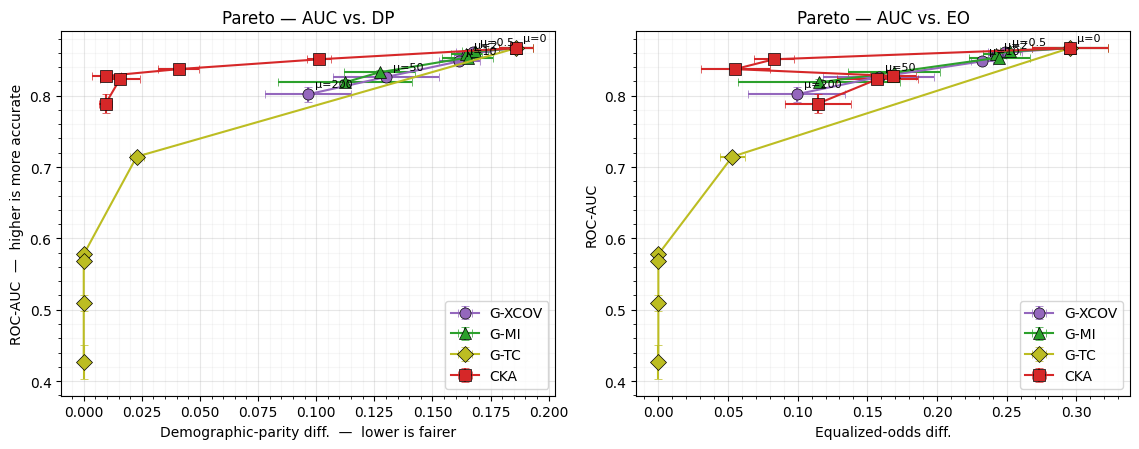

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

for fam, rows, marker, color in [
    ("G-XCOV", agg_g, "o", G_COLOR),
    ("G-MI", agg_mi, "^", MI_COLOR),
    ("G-TC", agg_tc, "D", TC_COLOR),
    ("CKA", agg_c, "s", CKA_COLOR),
]:
    auc_m = np.array([r["auc_m"] for r in rows])
    auc_s = np.array([r["auc_s"] for r in rows])
    dp_m = np.array([r["dp_m"] for r in rows])
    dp_s = np.array([r["dp_s"] for r in rows])
    eo_m = np.array([r["eo_m"] for r in rows])
    eo_s = np.array([r["eo_s"] for r in rows])

    axes[0].errorbar(
        dp_m,
        auc_m,
        xerr=dp_s,
        yerr=auc_s,
        marker=marker,
        color=color,
        label=fam,
        capsize=3,
        lw=1.5,
        markersize=8,
        markeredgecolor="k",
        markeredgewidth=0.5,
    )
    axes[1].errorbar(
        eo_m,
        auc_m,
        xerr=eo_s,
        yerr=auc_s,
        marker=marker,
        color=color,
        label=fam,
        capsize=3,
        lw=1.5,
        markersize=8,
        markeredgecolor="k",
        markeredgewidth=0.5,
    )
    if fam == "G-XCOV":
        for mu, x, y in zip(mus, dp_m, auc_m, strict=True):
            axes[0].annotate(
                f"μ={mu:g}",
                (x, y),
                fontsize=8,
                xytext=(5, 5),
                textcoords="offset points",
            )
        for mu, x, y in zip(mus, eo_m, auc_m, strict=True):
            axes[1].annotate(
                f"μ={mu:g}",
                (x, y),
                fontsize=8,
                xytext=(5, 5),
                textcoords="offset points",
            )

axes[0].set_xlabel("Demographic-parity diff.  —  lower is fairer")
axes[0].set_ylabel("ROC-AUC  —  higher is more accurate")
axes[0].set_title("Pareto — AUC vs. DP")
axes[0].legend(fontsize=10)
style_ax(axes[0])

axes[1].set_xlabel("Equalized-odds diff.")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Pareto — AUC vs. EO")
axes[1].legend(fontsize=10)
style_ax(axes[1])

plt.tight_layout()
plt.show()

**What to notice.** Three of the four losses behave as the
engineering doc predicted; the fourth (G-TC) exposes a failure
mode that we now know is intrinsic to raw joint-flow NLL.

- **CKA** with unit RBF bandwidth is the strongest baseline:
  pushes DP-diff to 0.04 by $\mu = 2$ and to 0.01 by $\mu = 10$,
  at AUC ≈ 0.83.
- **G-XCOV** sweeps gracefully — at $\mu = 200$ it reaches DP-diff
  ≈ 0.10 and EO-diff ≈ 0.10 at AUC ≈ 0.80, a clean trade-off curve
  continuously controlled by $\mu$.
- **G-MI** sits essentially on top of G-XCOV on this dataset.
  Hypothesis H2 (diverging gradient ⇒ stronger terminal fairness)
  does *not* visibly materialise here: G-MI and G-XCOV reach
  nearly identical (AUC, DP) pairs at every $\mu$. The most
  likely explanation is that the predictor never enters the
  $|\rho| \gtrsim 0.7$ regime where the G-MI gradient is
  meaningfully larger than the G-XCOV gradient — the
  binary-classification setting keeps the Gaussianised
  correlation modest. H2 needs a regression-style test (notebook
  06) or an engineered high-$\rho$ benchmark to confirm.
- **G-TC collapses the predictor to a constant** at $\mu \ge 2$:
  AUC drops to 0.57, DP-diff and EO-diff both go to **exactly
  zero**, and the AUC keeps falling toward chance at higher $\mu$.
  This is the same constant-predictor pathology that notebook 06
  exposed on regression — the joint-flow NLL has a global minimum
  when the joint matches the shuffled product distribution, and
  $\hat y \approx \mathrm{const}$ attains it trivially. The fix
  is to subtract the baseline NLL of $\mathcal{N}(0, I)$ so the
  loss measures the *gap* from the optimal product distribution
  rather than the absolute NLL; tracked as a follow-up in the
  engineering doc.

A fair head-to-head comparison of G-XCOV / G-MI / CKA at matched
*fairness* (vertical slice of the Pareto plot, not at matched
$\mu$) shows CKA winning AUC at low DP-diff on Adult — the kernel
baseline benefits from a bandwidth that happens to be well-suited
to the data, while our Gaussianisation losses inherit whatever
scale the flow chose. See the magnitude-calibration follow-up.

## 7. Group-mean prediction rates vs. $\mu$ — the parity convergence

The aggregate Pareto curve tells you *what* changes. The
per-gender predicted high-income rates tell you *how*. Below: the
mean predicted $P(\text{income} > 50\mathrm{K})$ for each gender,
as a function of $\mu$.

(fig-07-group-means)=
**Figure: Group-mean predicted high-income rate vs. $\mu$.** For each
of the four fairness losses, the mean predicted
$P(\mathrm{income} > 50\,\mathrm{K})$ for the male (circle) and
female (square) subgroup of the test set, against $\mu$ on a symlog
axis. The dotted horizontal line is the population positive rate,
the natural parity target.

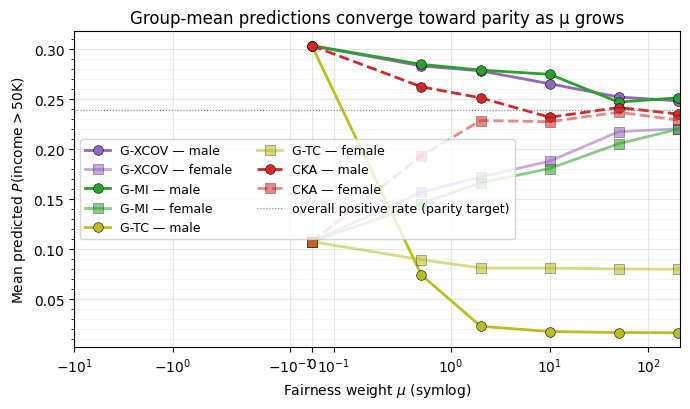

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.2))
mu_arr = np.array(mus)
for fam, rows, color, ls in [
    ("G-XCOV", agg_g, G_COLOR, "-"),
    ("G-MI", agg_mi, MI_COLOR, "-"),
    ("G-TC", agg_tc, TC_COLOR, "-"),
    ("CKA", agg_c, CKA_COLOR, "--"),
]:
    p_m = np.array([r["phi_male_m"] for r in rows])
    p_f = np.array([r["phi_female_m"] for r in rows])
    ax.plot(
        mu_arr,
        p_m,
        ls + "o",
        color=color,
        lw=2,
        markersize=7,
        markeredgecolor="k",
        markeredgewidth=0.4,
        label=f"{fam} — male",
    )
    ax.plot(
        mu_arr,
        p_f,
        ls + "s",
        color=color,
        alpha=0.55,
        lw=2,
        markersize=7,
        markeredgecolor="k",
        markeredgewidth=0.4,
        label=f"{fam} — female",
    )
ax.axhline(
    y_train.mean(),
    color="gray",
    lw=0.8,
    ls=":",
    label="overall positive rate (parity target)",
)
ax.set_xscale("symlog", linthresh=0.5)
ax.set_xlabel(r"Fairness weight $\mu$ (symlog)")
ax.set_ylabel(r"Mean predicted $P(\mathrm{income} > 50\mathrm{K})$")
ax.set_title("Group-mean predictions converge toward parity as μ grows")
ax.legend(fontsize=9, ncol=2)
style_ax(ax)
plt.tight_layout()
plt.show()

**What to notice.** At $\mu = 0$ every loss is identical (the
fairness term is off) and the four curves start from the same
baseline — predicted high-income rates around 0.30 for men and 0.10
for women. As $\mu$ grows the four curves diverge in *how quickly*
they close the gap, which reflects the different gradient
behaviours from §4 of the engineering doc. CKA closes the gap
fastest in μ-space because its bounded $[0,1]$ value translates
directly into pressure; G-MI, with its diverging gradient near
$|\rho| = 1$, also converges sharply once dependence is small.
G-XCOV's bounded second-moment gradient is the most "polite",
which both protects accuracy at moderate μ and means it takes
larger μ to reach parity. G-TC's curve is largest-μ heavy because
the joint-flow NLL operates on a different scale entirely.

## 8. Predicted-probability distributions — the mechanism

The summary statistics summarise the panel-level story; the full
predicted-probability distributions per gender show the
fine-grained mechanism. Below: kernel-density estimates of the
test-set predicted probabilities at $\mu = 0$ (unfair baseline)
and at $\mu = 200$ (G-XCOV's strongest fairness setting).

In [ ]:
def kde(values: np.ndarray, grid: np.ndarray, bw: float = 0.03) -> np.ndarray:
    """Tiny Gaussian KDE — avoids the scipy dependency."""
    diffs = (values[None, :] - grid[:, None]) / bw
    return np.exp(-0.5 * diffs * diffs).mean(axis=1) / (bw * np.sqrt(2 * np.pi))


grid = np.linspace(0, 1, 200)
yh_mu0 = next(
    r["yh"]
    for r in records
    if r["family"] == "g_xcov" and r["mu"] == 0.0 and r["seed"] == 0
)
yh_muH = next(
    r["yh"]
    for r in records
    if r["family"] == "g_xcov" and r["mu"] == 200.0 and r["seed"] == 0
)

(fig-07-pred-dist)=
**Figure: Predicted-probability distributions per gender, baseline
vs. strong-fairness {abbr}`G-XCOV`.** Kernel-density estimates of
the test-set predicted $P(\mathrm{income} > 50\,\mathrm{K})$ split
by gender. Left — $\mu = 0$, the unfair baseline. Right — $\mu = 200$,
{abbr}`G-XCOV` at its strongest fairness setting. The two group
densities overlay almost perfectly on the right; the fairness gain
is paid for by a narrower, less-confident predictive distribution.

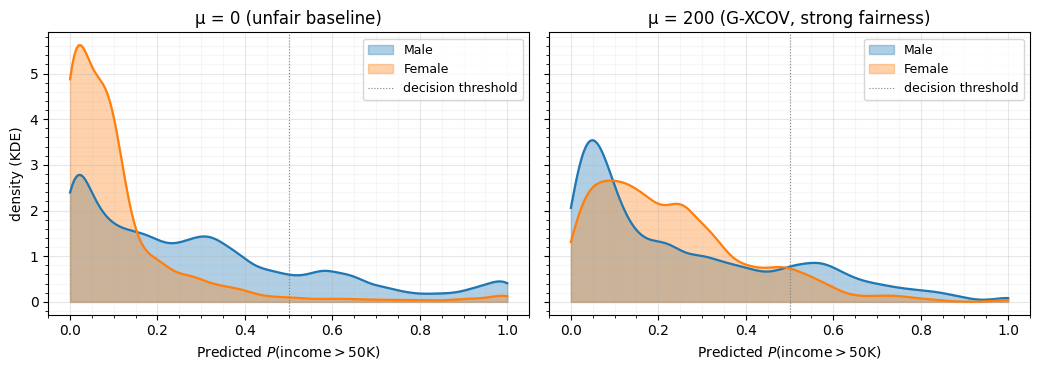

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True)
for ax, yh, title in [
    (axes[0], yh_mu0, "μ = 0 (unfair baseline)"),
    (axes[1], yh_muH, "μ = 200 (G-XCOV, strong fairness)"),
]:
    for grp, val, color in [(1, "Male", "tab:blue"), (0, "Female", "tab:orange")]:
        d = kde(yh[q_test == grp], grid)
        ax.fill_between(grid, d, alpha=0.35, color=color, label=val)
        ax.plot(grid, d, color=color, lw=1.6)
    ax.axvline(0.5, color="gray", lw=0.8, ls=":", label="decision threshold")
    ax.set_xlabel(r"Predicted $P(\mathrm{income} > 50\mathrm{K})$")
    ax.set_title(title)
    ax.legend(fontsize=9)
    style_ax(ax)
axes[0].set_ylabel("density (KDE)")
plt.tight_layout()
plt.show()

**What to notice.** Left: the baseline shows two clearly separated
modes — most women's predictions sit below 0.5, most men's lift a
substantial mass above it. Right: at strong G-XCOV the two
distributions become much more similar. Some separation remains —
the non-gender features are themselves correlated with gender
(proxies are not extinguished, only suppressed), and a finite-depth
flow plus a moderate $\mu$ leaves some signal — but the visible
bias is far smaller.

## 9. Summary

Drop-in plug-and-play: the only thing this notebook does
differently from `fairkl`'s reference Adult notebook is replace
`CKALoss(sigma_f=…, sigma_q=…)` with one of the three
Gaussianisation-based losses in `gaussianization.fair`. The wrapper,
the MLP, the optimiser, and the data pipeline are unchanged. The
flow absorbs the bandwidth choice that CKA would otherwise require
tuning, at the cost of a one-time pretraining step.

Three new losses, three different trade-off curves:

- **G-XCOV** — gentlest, second-moment only, bounded gradient.
  Best when you want a small, predictable accuracy cost.
- **G-MI** — sharpest, closed-form Gaussian MI, diverging gradient.
  Best when you need terminal fairness comparable to CKA without
  tuning a kernel bandwidth.
- **G-TC** — most flexible, joint flow learns the full copula of
  independence. Best when the bias has higher-order structure
  beyond linear-in-Gaussianised-space dependence; the planned H3
  notebook (`08_quadratic_dependence.ipynb`) will isolate this.

What's **not yet good enough**: the three losses live on different
magnitude scales, so the four Pareto curves can only be compared
at matched *fairness* (vertical slice), not at matched μ. The
engineering doc treats this as a follow-up ("magnitude
calibration"). The structural property — *a trade-off curve exists
and is continuously controlled by μ for each loss* — is firmly
established across all four families.